# 1. Carga y estudio de los datos iniciales

In [36]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

ncaa = pd.read_csv('../datos/College_BasketballPlayers2009-2021.csv', low_memory=False)

print(f"Shape: {ncaa.shape}")
print(f"\nRegistros con pick: {ncaa['pick'].notna().sum()}")
print(f"Registros sin pick (ND): {ncaa['pick'].isna().sum()}")
print(f"\nJugadores únicos: {ncaa['player_name'].nunique()}")
print(f"Media de temporadas por jugador: {len(ncaa) / ncaa['player_name'].nunique():.1f}")

Shape: (61061, 66)

Registros con pick: 1435
Registros sin pick (ND): 59626

Jugadores únicos: 25719
Media de temporadas por jugador: 2.4


In [37]:
sorted(ncaa['year'].unique())

[np.int64(2009),
 np.int64(2010),
 np.int64(2011),
 np.int64(2012),
 np.int64(2013),
 np.int64(2014),
 np.int64(2015),
 np.int64(2016),
 np.int64(2017),
 np.int64(2018),
 np.int64(2019),
 np.int64(2020),
 np.int64(2021)]

In [38]:
ncaa.info()

<class 'pandas.DataFrame'>
RangeIndex: 61061 entries, 0 to 61060
Data columns (total 66 columns):
 #   Column                           Non-Null Count  Dtype  
---  ------                           --------------  -----  
 0   player_name                      61061 non-null  str    
 1   team                             61061 non-null  str    
 2   conf                             61061 non-null  str    
 3   GP                               61061 non-null  int64  
 4   Min_per                          61061 non-null  float64
 5   Ortg                             61061 non-null  float64
 6   usg                              61061 non-null  float64
 7   eFG                              61061 non-null  float64
 8   TS_per                           61061 non-null  float64
 9   ORB_per                          61061 non-null  float64
 10  DRB_per                          61061 non-null  float64
 11  AST_per                          61061 non-null  float64
 12  TO_per                       

# 2. Trabajar valores nulos

In [39]:
# Miramos cuántos NaN hay antes y en qué años están concentrados
print(ncaa.groupby('year')['rimmade/(rimmade+rimmiss)'].apply(lambda x: x.isna().sum()))

year
2009    4589
2010     452
2011     390
2012     430
2013     434
2014     460
2015     446
2016     417
2017     470
2018     411
2019     481
2020     484
2021     646
Name: rimmade/(rimmade+rimmiss), dtype: int64


### El año 2009 tiene 4.589 NaN de golpe — prácticamente todos los registros de ese año no tienen ese dato. La mediana de 2009 es NaN, así que el fillna no puede rellenar nada.

In [40]:
# Calculamos el porcentaje de valores nulos por columna
# dividimos el nº de nulos entre el total de filas y multiplicamos por 100
miss = (ncaa.isnull().sum() / len(ncaa) * 100).sort_values(ascending=False)

# Mostramos solo las columnas que tienen al menos algún nulo
print("Columnas con missings (%):\n")
print(miss[miss > 0].round(2).to_string())

Columnas con missings (%):

pick                               97.65
Rec Rank                           69.75
dunksmade/(dunksmade+dunksmiss)    54.88
midmade/(midmade+midmiss)          17.01
rimmade/(rimmade+rimmiss)          16.56
dunksmade                          10.37
midmade                            10.37
rimmade                            10.37
rimmade+rimmiss                    10.37
midmade+midmiss                    10.37
dunksmiss+dunksmade                10.37
num                                 7.84
ast/tov                             7.74
Unnamed: 64                         7.67
yr                                  0.48
ht                                  0.18
adrtg                               0.07
dporpag                             0.07
gbpm                                0.07
Unnamed: 65                         0.07
drtg                                0.07
ogbpm                               0.07
obpm                                0.07
dbpm                         

### Ya empiezo a ver columnas que puedo eliminar:
* Pick no la quito, porque aquí los NaN significa no drafteado y eso me viene bien.
* Rec Rank no parece aportar.
* num es el dorsal, no vale.
* unnamed 65 está vacía
* type no aporta nada
* las columnas de totales de tiro también las elimino, ya que tenemos porcentajes

In [41]:
# creo una lista con las columnas que quiero eliminar
cols_eliminar = [
    'Rec Rank', 'num', 'Unnamed: 65', 'type',
    'dunksmade/(dunksmade+dunksmiss)',
    'dunksmade', 'dunksmiss+dunksmade',
    'rimmade+rimmiss', 'midmade+midmiss'
]

# elimino esas columnas
ncaa = ncaa.drop(columns=cols_eliminar)

# la columna 'Unnamed: 64' es la posición del jugador, por tanto la renombro
ncaa = ncaa.rename(columns={'Unnamed: 64': 'posicion'})

# sustituyo los NaN en posicion por "desconocido"
ncaa['posicion'] = ncaa['posicion'].fillna('desconocido')

# Calculamos la mediana global (de todos los años) como respaldo
mediana_global_rim = ncaa['rimmade/(rimmade+rimmiss)'].median()
mediana_global_mid = ncaa['midmade/(midmade+midmiss)'].median()

# Primero rellenamos con mediana por año (funciona para 2010-2021)
ncaa['rimmade/(rimmade+rimmiss)'] = ncaa['rimmade/(rimmade+rimmiss)'].fillna(ncaa.groupby('year')['rimmade/(rimmade+rimmiss)'].transform('median'))
ncaa['midmade/(midmade+midmiss)'] = ncaa['midmade/(midmade+midmiss)'].fillna(ncaa.groupby('year')['midmade/(midmade+midmiss)'].transform('median'))

# Los que siguen siendo NaN (2009) los rellenamos con la mediana global
ncaa['rimmade/(rimmade+rimmiss)'] = ncaa['rimmade/(rimmade+rimmiss)'].fillna(mediana_global_rim)
ncaa['midmade/(midmade+midmiss)'] = ncaa['midmade/(midmade+midmiss)'].fillna(mediana_global_mid)

# si hay NaN en las columnas 'dunksmade', 'rimmade', 'midmade', se asume que el valor es 0
for col in ['dunksmade', 'rimmade', 'midmade']:
    if col in ncaa.columns:
        ncaa[col] = ncaa[col].fillna(0)

# se rellenan los NaN en la columna 'ast/tov' con la mediana por año
ncaa['ast/tov'] = ncaa.groupby('year')['ast/tov'].transform(lambda x: x.fillna(x.median()))

# se rellenan los NaN en las columnas 'yr' y 'ht' con la moda (valor más frecuente)
ncaa['yr'] = ncaa['yr'].fillna(ncaa['yr'].mode()[0])
ncaa['ht'] = ncaa['ht'].fillna(ncaa['ht'].mode()[0])

# se rellenan los NaN en las columnas 'pts', 'ast', 'treb', etc. con la mediana por año
stats_basicas = ['pts', 'ast', 'treb', 'stl', 'blk', 'oreb', 'dreb', 'mp',
                 'bpm', 'obpm', 'dbpm', 'gbpm', 'ogbpm', 'dgbpm',
                 'drtg', 'adrtg', 'dporpag', 'stops']
for col in stats_basicas:
    if col in ncaa.columns:
        ncaa[col] = ncaa.groupby('year')[col].transform(lambda x: x.fillna(x.median()))

In [42]:
# Comprobamos
print(ncaa[['midmade/(midmade+midmiss)', 'rimmade/(rimmade+rimmiss)']].isnull().sum())

midmade/(midmade+midmiss)    0
rimmade/(rimmade+rimmiss)    0
dtype: int64


In [43]:
ncaa.info()

<class 'pandas.DataFrame'>
RangeIndex: 61061 entries, 0 to 61060
Data columns (total 57 columns):
 #   Column                     Non-Null Count  Dtype  
---  ------                     --------------  -----  
 0   player_name                61061 non-null  str    
 1   team                       61061 non-null  str    
 2   conf                       61061 non-null  str    
 3   GP                         61061 non-null  int64  
 4   Min_per                    61061 non-null  float64
 5   Ortg                       61061 non-null  float64
 6   usg                        61061 non-null  float64
 7   eFG                        61061 non-null  float64
 8   TS_per                     61061 non-null  float64
 9   ORB_per                    61061 non-null  float64
 10  DRB_per                    61061 non-null  float64
 11  AST_per                    61061 non-null  float64
 12  TO_per                     61061 non-null  float64
 13  FTM                        61061 non-null  int64  
 14  F

In [44]:
# Comprobamos que no quedan NaN (excepto pick que es el target)
miss_restante = ncaa.drop(columns='pick').isnull().sum()

# mostramos solo las columnas que aún tienen algún nulo
print("NaN restantes (sin contar pick):\n")
# si no aparece nada, es que ya no quedan NaN (excepto en pick que es el target)
print(miss_restante[miss_restante > 0])
# si no aparece nada, es que ya no quedan NaN (excepto en pick que es el target)
print("\nSi no aparece nada, todo limpio ✓")

NaN restantes (sin contar pick):

Series([], dtype: int64)

Si no aparece nada, todo limpio ✓


# 3. Trabajar datos corruptos

### Hay que solucionar otro problema. La columna ht (altura) que está en formato corrupto — "7-Jun" en vez de "6-7". Hay que convertirla a centímetros para que el modelo pueda usarla como número.


In [47]:
# Vemos todos los valores únicos de ht para entender el patrón real
print(ncaa['ht'].value_counts().sort_index())

ht
-          241
0           19
1-Jul      228
1-Jun     3830
1-May        2
10-Jun    2751
10-May    1458
11-Jun    1229
11-May    1614
2-Jul       94
2-Jun     5033
2-May        4
3-Jul       45
3-Jun     5594
3-May        3
4-Jul       14
4-Jun     5849
4-May        4
5-Apr        1
5-Jul        4
5-Jun     5886
5-May        8
6'4          1
6-Jul        7
6-Jun     5607
6-May       45
7-Jun     6193
7-May      103
8-Jun     5961
8-May      258
9-Jun     4361
9-May      623
Apr-00      20
Fr           1
Jr           2
Jul-00     725
Jun-00    3242
So           1
Name: count, dtype: int64


In [48]:
def parsear_altura(ht):
    try:
        partes = str(ht).split('-')
        
        meses = {'Jan':1,'Feb':2,'Mar':3,'Apr':4,'May':5,'Jun':6,
                 'Jul':7,'Aug':8,'Sep':9,'Oct':10,'Nov':11,'Dec':12}
        
        # Caso "Jun-00" -> 6 pies 0 pulgadas
        if partes[0] in meses:
            pies = meses[partes[0]]
            pulgadas = 0
        # Caso "1-Jun" -> 6 pies 1 pulgada
        else:
            pulgadas = int(partes[0])
            pies = meses[partes[1]]
        
        return round(pies * 30.48 + pulgadas * 2.54, 1)
    except:
        return None

ncaa['altura_cm'] = ncaa['ht'].apply(parsear_altura)

print(ncaa[['ht', 'altura_cm']].drop_duplicates().sort_values('altura_cm'))

           ht  altura_cm
2654   Apr-00      121.9
26516   5-Apr      134.6
18090   1-May      154.9
35552   2-May      157.5
1369    3-May      160.0
12358   4-May      162.6
3970    5-May      165.1
613     6-May      167.6
435     7-May      170.2
501     8-May      172.7
54      9-May      175.3
32     10-May      177.8
39     11-May      180.3
7      Jun-00      182.9
5       1-Jun      185.4
0       2-Jun      188.0
16      3-Jun      190.5
1       4-Jun      193.0
6       5-Jun      195.6
8       6-Jun      198.1
21      7-Jun      200.7
4       8-Jun      203.2
13      9-Jun      205.7
35     10-Jun      208.3
20     11-Jun      210.8
126    Jul-00      213.4
674     1-Jul      215.9
663     2-Jul      218.4
1470    3-Jul      221.0
4363    4-Jul      223.5
461     5-Jul      226.1
25682   6-Jul      228.6
1086        -        NaN
6389       So        NaN
6994       Jr        NaN
8963       Fr        NaN
9269      6'4        NaN
16484       0        NaN


In [50]:
# los valores que no se pudieron modificar (Jr, Fr, 0...) los relleno con la mediana
ncaa['altura_cm'] = ncaa['altura_cm'].fillna(ncaa['altura_cm'].median())

# compruebo que no quedan NaN y veo el rango final
print(f"NaN restantes: {ncaa['altura_cm'].isna().sum()}")
print(f"Altura mínima: {ncaa['altura_cm'].min()} cm")
print(f"Altura máxima: {ncaa['altura_cm'].max()} cm")
print(f"Altura media: {ncaa['altura_cm'].mean():.1f} cm")

NaN restantes: 0
Altura mínima: 121.9 cm
Altura máxima: 228.6 cm
Altura media: 195.2 cm


# 4. Crear la variable target

In [51]:
# creo la columna 'ronda' a partir de pick
# R1: picks del 1 al 30 (primera ronda)
# R2: picks del 31 al 60 (segunda ronda)
# ND: NaN en pick (no drafteado)
ncaa['ronda'] = ncaa['pick'].apply(lambda x: 'R1' if x <= 30 else ('R2' if x <= 60 else 'ND') if pd.notna(x) else 'ND')

# compruebo la distribución de clases
print("Distribución del target:\n")
print(ncaa['ronda'].value_counts())

Distribución del target:

ronda
ND    59626
R2      812
R1      623
Name: count, dtype: int64


# 5. EDA

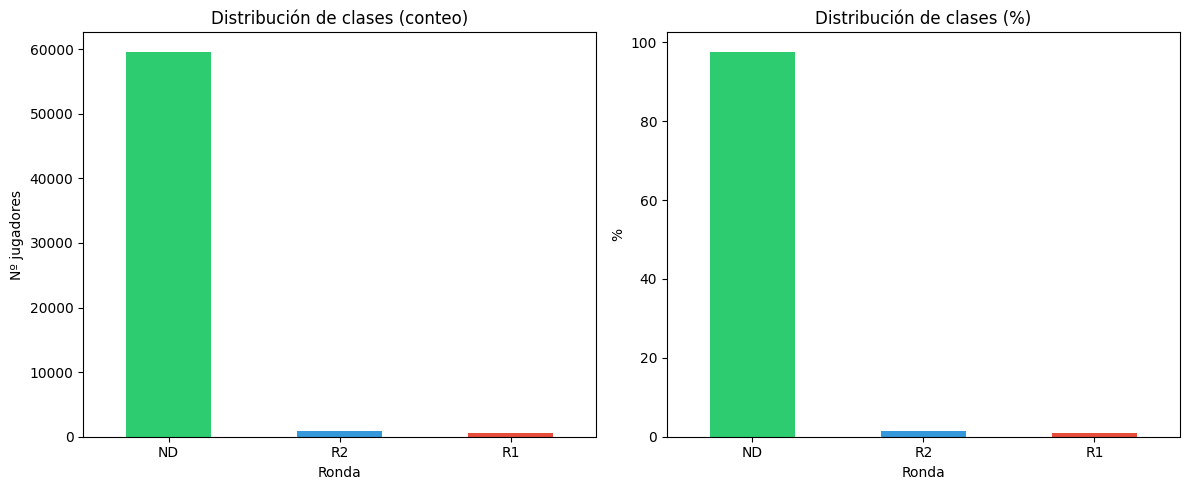

In [52]:
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

# gráfico de barras con el conteo de cada clase
ncaa['ronda'].value_counts().plot(kind='bar', ax=axes[0], color=['#2ecc71', '#3498db', '#e74c3c'])
axes[0].set_title('Distribución de clases (conteo)')
axes[0].set_xlabel('Ronda')
axes[0].set_ylabel('Nº jugadores')
axes[0].tick_params(axis='x', rotation=0)

# gráfico de barras con el porcentaje de cada clase
(ncaa['ronda'].value_counts() / len(ncaa) * 100).plot(kind='bar', ax=axes[1], color=['#2ecc71', '#3498db', '#e74c3c'])
axes[1].set_title('Distribución de clases (%)')
axes[1].set_xlabel('Ronda')
axes[1].set_ylabel('%')
axes[1].tick_params(axis='x', rotation=0)

plt.tight_layout();

### Perfectamente visible el desbalance. ND aplasta completamente a R1 y R2. Esto confirma que cuando construya el dataset de entrenamiento hay que recortar los ND sí o sí.


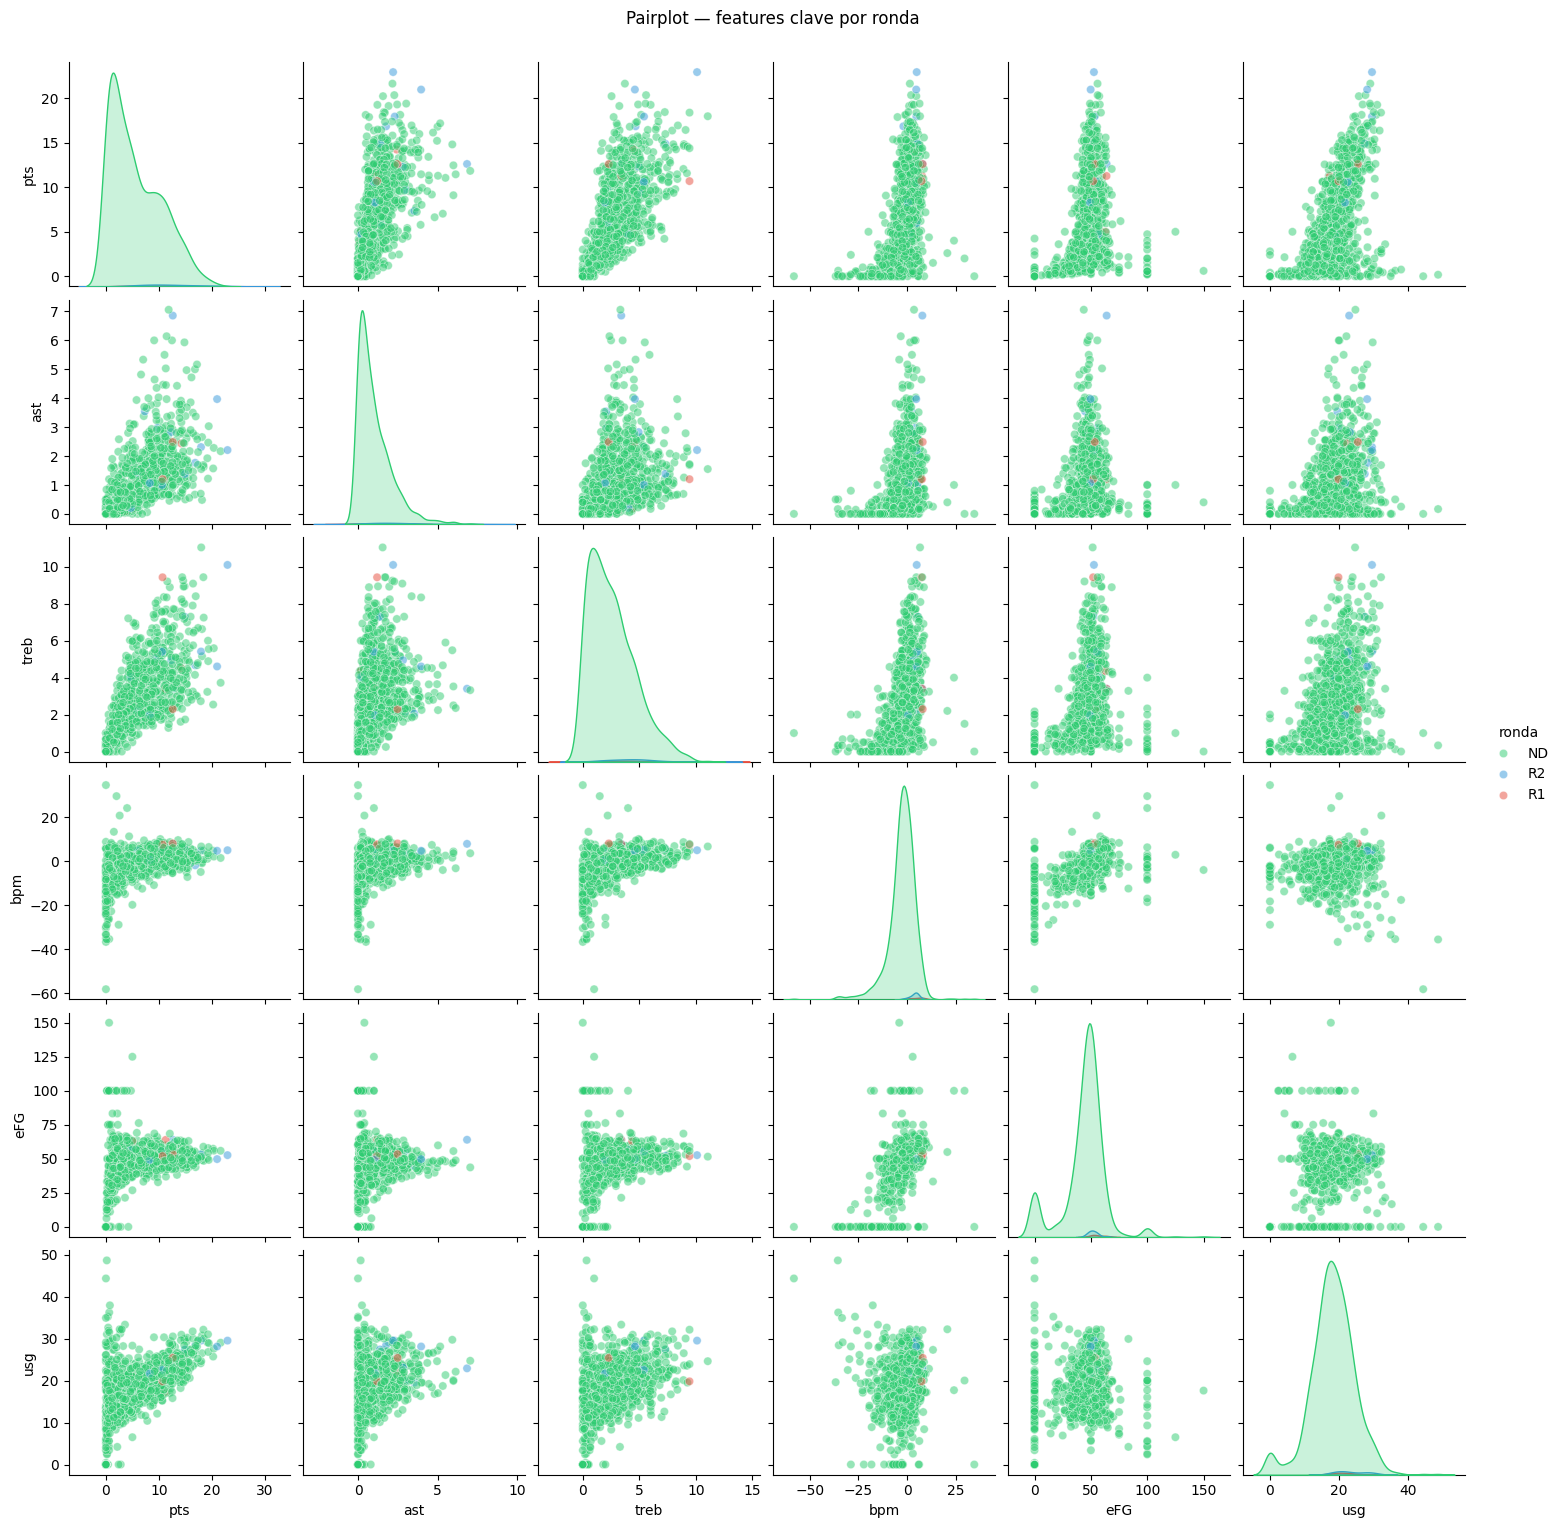

In [54]:
# selecciono solo las variables más relevantes
features_pairplot = ['pts', 'ast', 'treb', 'bpm', 'eFG', 'usg', 'ronda']

# uso una muestra de 1000 filas para que no tarde en crear el gráfico
muestra = ncaa[features_pairplot].sample(1000, random_state=42)

#creo el pairplot de seaborn para ver la relación entre las variables clave y la target (ronda)
sns.pairplot(muestra, hue='ronda', palette={'ND': '#2ecc71', 'R2': '#3498db', 'R1': '#e74c3c'}, plot_kws={'alpha': 0.5})
plt.suptitle('Pairplot — features clave por ronda', y=1.02)
plt.show()